# Q1 Patchwise Instantaneous Static and Oscillating Field Comparison

This notebook uses the patchwise instantaneous-basis reduced model for `transitions.Q1_F1_1o2_F0`. It compares static `0 V/cm` and `100 V/cm` against the tracked exact compact reduced model, then runs an oscillating `0 -> 50 V/cm` field with discrete patch switching.

In [1]:
from importlib.machinery import SourceFileLoader
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from centrex_tlf import couplings, transitions

runtime_relpath = Path(
    "examples/effective hamiltonian/effective_hamiltonian_runtime.py"
)
repo_root = next(
    (
        candidate
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / runtime_relpath).exists()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError(runtime_relpath)

ehr = SourceFileLoader("ehr", str(repo_root / runtime_relpath)).load_module()

In [2]:
TRANSITION = transitions.Q1_F1_1o2_F0
OPTICAL_POLARIZATION = couplings.polarization_Z
B_FIELD = (0.0, 0.0, 1e-5)
PATCH_POINTS_VCM = [0.0, 5.0, 10.0, 20.0, 30.0, 40.0, 50.0, 75.0, 100.0]
MASTER_FIELD_VCM = 0.0

RABI_RATE = 2.0 * np.pi * 1e6
DETUNING = 0.0
T_FINAL = 10e-6
N_T = 400
T_EVAL = np.linspace(0.0, T_FINAL, N_T)

OSC_AMPLITUDE_VCM = 25.0
OSC_FREQUENCY_HZ = 100e3
OSC_OMEGA = 2.0 * np.pi * OSC_FREQUENCY_HZ

In [3]:
patchwise_model = ehr.prepare_patchwise_instantaneous_effective_model(
    field_points=PATCH_POINTS_VCM,
    transition=TRANSITION,
    optical_polarization=OPTICAL_POLARIZATION,
    magnetic_field=B_FIELD,
    master_field=MASTER_FIELD_VCM,
)

(
    patchwise_model.n_effective_states,
    patchwise_model.ground_indices.tolist(),
    patchwise_model.sink_indices.tolist(),
    patchwise_model.excited_indices.tolist(),
)

(15, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [12, 13], [14])

In [4]:
def bright_ground_index(bundle):
    return int(ehr._optically_bright_ground_index(bundle, bundle.excited_indices))


def rho0_from_index(n_states, index):
    rho0 = np.zeros((n_states, n_states), dtype=np.complex128)
    rho0[index, index] = 1.0
    return rho0


def tracked_exact_bundle(field_vcm):
    _, _, bundle = ehr._tracked_exact_compact_bundle_for_field(
        patchwise_model.base_model, (0.0, 0.0, field_vcm)
    )
    return bundle


def static_compact_case(field_vcm):
    system, bundle = ehr.build_compact_reference_decomposed_bundle(
        transition=TRANSITION,
        optical_polarization=OPTICAL_POLARIZATION,
        electric_field=(0.0, 0.0, field_vcm),
        magnetic_field=B_FIELD,
    )
    rho0 = rho0_from_index(bundle.h_internal.shape[0], bright_ground_index(bundle))
    sol = ehr.solve_static_density_matrix_bundle(
        bundle,
        rho0=rho0,
        t_span=(0.0, T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=T_EVAL,
    )
    rho_t = ehr.solution_to_density_matrices(sol, bundle.h_internal.shape[0])
    jump_rate = bundle.jump_rate_operator()
    rate_t = ehr.scattering_signal(rho_t, jump_rate)
    photons = ehr.integrated_scattering_probability(T_EVAL, rho_t, jump_rate)
    return dict(
        system=system,
        bundle=bundle,
        solution=sol,
        rho_t=rho_t,
        rate_t=rate_t,
        photons=photons,
    )


def static_patchwise_case(field_vcm):
    patch_index = patchwise_model.patch_index_for_field(field_vcm)
    bundle = patchwise_model.patch_bundle(patch_index)
    rho0 = ehr.default_effective_density_matrix(patchwise_model)
    sol = ehr.solve_static_patchwise_instantaneous_model(
        patchwise_model,
        electric_field=field_vcm,
        magnetic_field=B_FIELD,
        rho0=rho0,
        t_span=(0.0, T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=T_EVAL,
    )
    rho_t = ehr.solution_to_density_matrices(sol, bundle.h_internal.shape[0])
    jump_rate = bundle.jump_rate_operator()
    rate_t = ehr.scattering_signal(rho_t, jump_rate)
    photons = ehr.integrated_scattering_probability(T_EVAL, rho_t, jump_rate)
    return dict(
        patch_index=patch_index,
        bundle=bundle,
        solution=sol,
        rho_t=rho_t,
        rate_t=rate_t,
        photons=photons,
    )


def oscillating_field(t):
    return (0.0, 0.0, OSC_AMPLITUDE_VCM * (1.0 - np.cos(OSC_OMEGA * t)))


def oscillating_patchwise_case():
    rho0 = ehr.default_effective_density_matrix(patchwise_model)
    sol = ehr.solve_patchwise_instantaneous_model(
        patchwise_model,
        electric_field=oscillating_field,
        magnetic_field=B_FIELD,
        rho0=rho0,
        t_span=(0.0, T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=T_EVAL,
    )
    bundle_cache = {}
    rate_t = np.empty(sol.t.size, dtype=np.float64)
    for idx, (t, rho_flat, patch_index) in enumerate(
        zip(sol.t, sol.y.T, sol.patch_indices)
    ):
        patch_index = int(patch_index)
        bundle = bundle_cache.setdefault(
            patch_index, patchwise_model.patch_bundle(patch_index)
        )
        rho = rho_flat.reshape(
            (patchwise_model.n_effective_states, patchwise_model.n_effective_states)
        )
        rate_t[idx] = np.real(np.trace(rho @ bundle.jump_rate_operator()))
    photons = float(np.trapezoid(rate_t, x=sol.t))
    return dict(solution=sol, rate_t=rate_t, photons=photons)

In [5]:
static_compact_0 = static_compact_case(0.0)
static_patchwise_0 = static_patchwise_case(0.0)
static_compact_100 = static_compact_case(100.0)
static_patchwise_100 = static_patchwise_case(100.0)
osc_patchwise = oscillating_patchwise_case()

In [6]:
tracked_exact_0 = tracked_exact_bundle(0.0)
tracked_exact_100 = tracked_exact_bundle(100.0)

operator_checks = pd.DataFrame(
    [
        {
            "field_vcm": 0.0,
            "patch_index": static_patchwise_0["patch_index"],
            "h_internal_max_abs_diff": float(
                np.max(
                    np.abs(
                        static_patchwise_0["bundle"].h_internal
                        - tracked_exact_0.h_internal
                    )
                )
            ),
            "h_opt_max_abs_diff": float(
                np.max(
                    np.abs(static_patchwise_0["bundle"].h_opt - tracked_exact_0.h_opt)
                )
            ),
            "dissipator_max_abs_diff": float(
                np.max(
                    np.abs(
                        static_patchwise_0["bundle"].dissipator_superoperator()
                        - tracked_exact_0.dissipator_superoperator()
                    )
                )
            ),
        },
        {
            "field_vcm": 100.0,
            "patch_index": static_patchwise_100["patch_index"],
            "h_internal_max_abs_diff": float(
                np.max(
                    np.abs(
                        static_patchwise_100["bundle"].h_internal
                        - tracked_exact_100.h_internal
                    )
                )
            ),
            "h_opt_max_abs_diff": float(
                np.max(
                    np.abs(
                        static_patchwise_100["bundle"].h_opt - tracked_exact_100.h_opt
                    )
                )
            ),
            "dissipator_max_abs_diff": float(
                np.max(
                    np.abs(
                        static_patchwise_100["bundle"].dissipator_superoperator()
                        - tracked_exact_100.dissipator_superoperator()
                    )
                )
            ),
        },
    ]
)
operator_checks

,field_vcm,patch_index,h_internal_max_abs_diff,h_opt_max_abs_diff,dissipator_max_abs_diff
0,0.0,0,0.0,0.0,0.0
1,100.0,8,0.0,0.0,0.0


In [7]:
summary = pd.DataFrame(
    [
        {"case": "static compact 0 V/cm", "photons": static_compact_0["photons"]},
        {"case": "static patchwise 0 V/cm", "photons": static_patchwise_0["photons"]},
        {"case": "static compact 100 V/cm", "photons": static_compact_100["photons"]},
        {
            "case": "static patchwise 100 V/cm",
            "photons": static_patchwise_100["photons"],
        },
        {
            "case": "oscillating patchwise 0->50 V/cm",
            "photons": osc_patchwise["photons"],
        },
    ]
)
summary["relative_to_static_compact_0"] = (
    summary["photons"] / static_compact_0["photons"] - 1.0
)
summary

,case,photons,relative_to_static_compact_0
0,static compact 0 V/cm,1.154114e+00,0.000000e+00
1,static patchwise 0 V/cm,1.154110e+00,-3.224764e-06
2,static compact 100 V/cm,1.482712e+00,2.847184e-01
3,static patchwise 100 V/cm,1.482712e+00,2.847184e-01
4,oscillating patchwise 0->50 V/cm,-2.032303e+07,-1.760921e+07


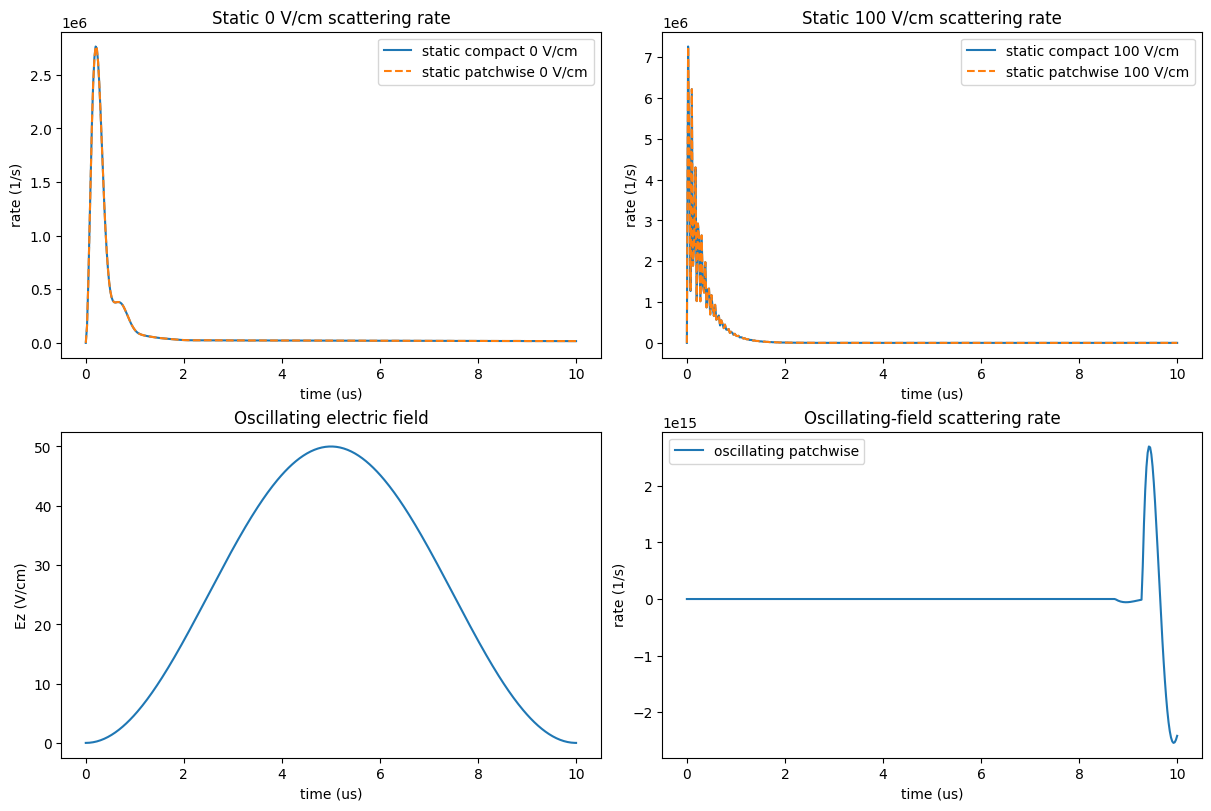

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

t_us = 1e6 * T_EVAL
osc_field = np.array([oscillating_field(t)[2] for t in T_EVAL], dtype=np.float64)

axes[0, 0].plot(t_us, static_compact_0["rate_t"], label="static compact 0 V/cm")
axes[0, 0].plot(
    t_us, static_patchwise_0["rate_t"], "--", label="static patchwise 0 V/cm"
)
axes[0, 0].set_title("Static 0 V/cm scattering rate")
axes[0, 0].set_xlabel("time (us)")
axes[0, 0].set_ylabel("rate (1/s)")
axes[0, 0].legend()

axes[0, 1].plot(t_us, static_compact_100["rate_t"], label="static compact 100 V/cm")
axes[0, 1].plot(
    t_us, static_patchwise_100["rate_t"], "--", label="static patchwise 100 V/cm"
)
axes[0, 1].set_title("Static 100 V/cm scattering rate")
axes[0, 1].set_xlabel("time (us)")
axes[0, 1].set_ylabel("rate (1/s)")
axes[0, 1].legend()

axes[1, 0].plot(t_us, osc_field)
axes[1, 0].set_title("Oscillating electric field")
axes[1, 0].set_xlabel("time (us)")
axes[1, 0].set_ylabel("Ez (V/cm)")

axes[1, 1].plot(
    1e6 * osc_patchwise["solution"].t,
    osc_patchwise["rate_t"],
    label="oscillating patchwise",
)
axes[1, 1].set_title("Oscillating-field scattering rate")
axes[1, 1].set_xlabel("time (us)")
axes[1, 1].set_ylabel("rate (1/s)")
axes[1, 1].legend()

plt.show()

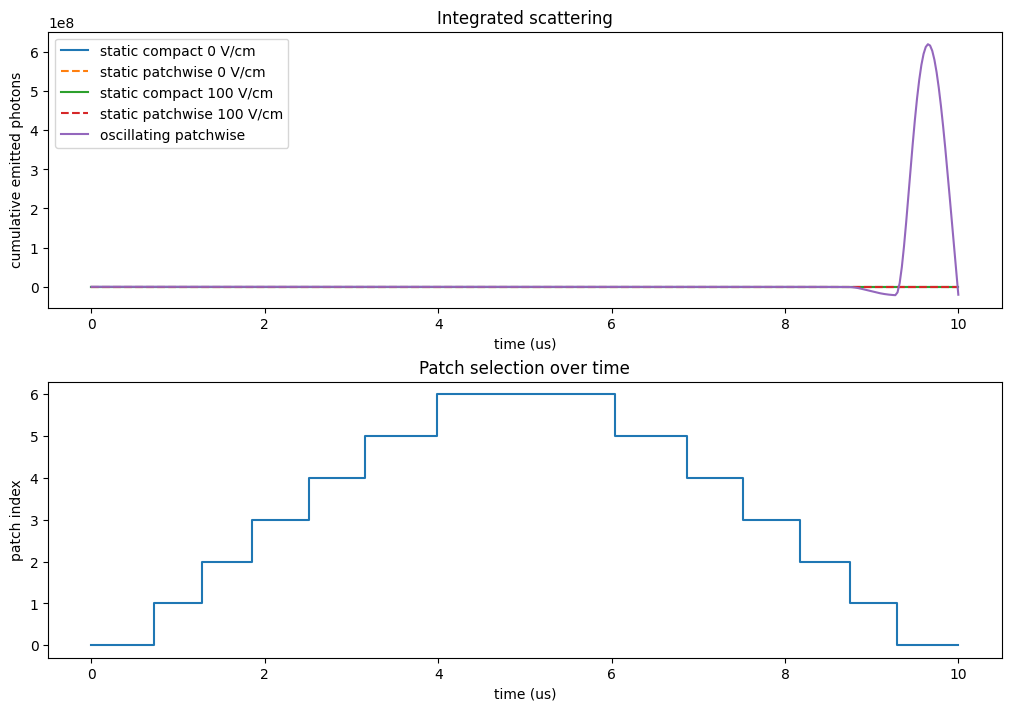

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)


def cumulative_from_rate(t, rate_t):
    return np.concatenate(
        [[0.0], np.cumsum(0.5 * (rate_t[1:] + rate_t[:-1]) * np.diff(t))]
    )


axes[0].plot(
    1e6 * T_EVAL,
    cumulative_from_rate(T_EVAL, static_compact_0["rate_t"]),
    label="static compact 0 V/cm",
)
axes[0].plot(
    1e6 * T_EVAL,
    cumulative_from_rate(T_EVAL, static_patchwise_0["rate_t"]),
    "--",
    label="static patchwise 0 V/cm",
)
axes[0].plot(
    1e6 * T_EVAL,
    cumulative_from_rate(T_EVAL, static_compact_100["rate_t"]),
    label="static compact 100 V/cm",
)
axes[0].plot(
    1e6 * T_EVAL,
    cumulative_from_rate(T_EVAL, static_patchwise_100["rate_t"]),
    "--",
    label="static patchwise 100 V/cm",
)
axes[0].plot(
    1e6 * osc_patchwise["solution"].t,
    cumulative_from_rate(osc_patchwise["solution"].t, osc_patchwise["rate_t"]),
    label="oscillating patchwise",
)
axes[0].set_xlabel("time (us)")
axes[0].set_ylabel("cumulative emitted photons")
axes[0].set_title("Integrated scattering")
axes[0].legend()

axes[1].step(
    1e6 * osc_patchwise["solution"].t,
    osc_patchwise["solution"].patch_indices,
    where="post",
)
axes[1].set_xlabel("time (us)")
axes[1].set_ylabel("patch index")
axes[1].set_title("Patch selection over time")

plt.show()